In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded successfully')

Libraries loaded successfully


## Step 1: Load Data

In [2]:
df = pd.read_csv('../datasets/diabetes.csv')
print('Shape:', df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print(df.info())
print('\nMissing values:\n', df.isnull().sum())
print('\nClass distribution:\n', df['Outcome'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age    

## Step 2: EDA

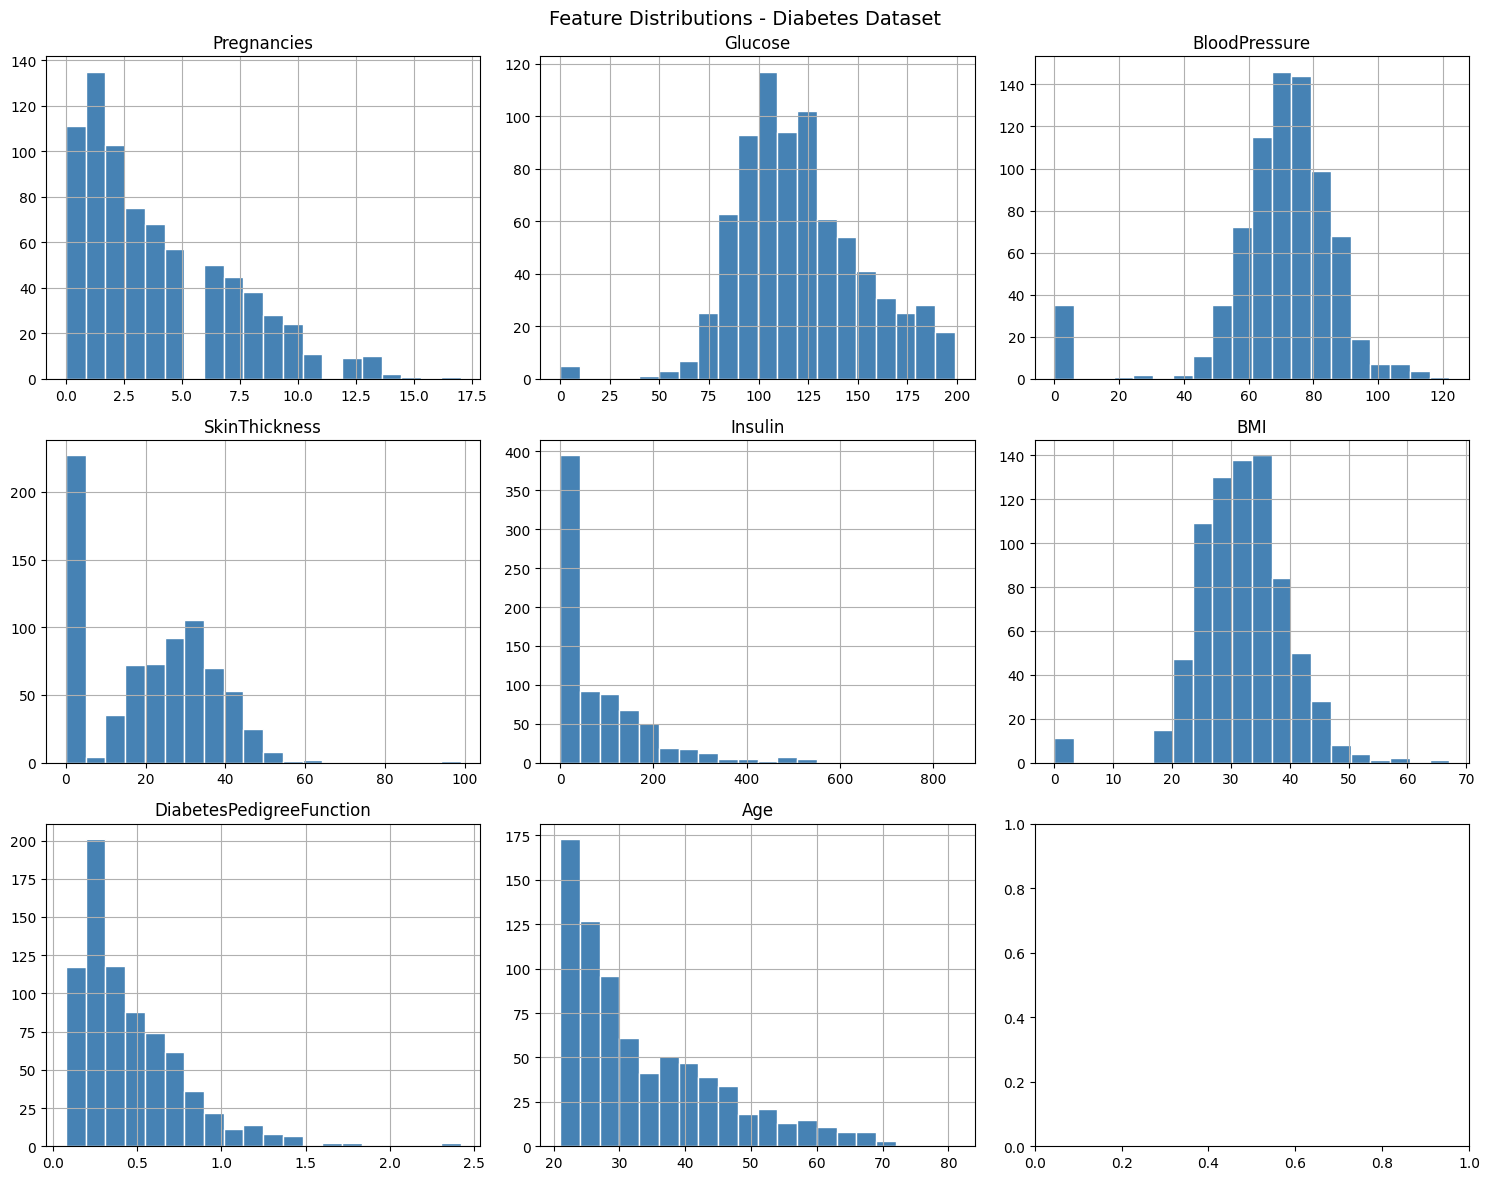

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, col in enumerate(df.columns[:-1]):
    ax = axes[i // 3][i % 3]
    df[col].hist(ax=ax, bins=20, color='steelblue', edgecolor='white')
    ax.set_title(col)
plt.suptitle('Feature Distributions - Diabetes Dataset', fontsize=14)
plt.tight_layout()
plt.show()

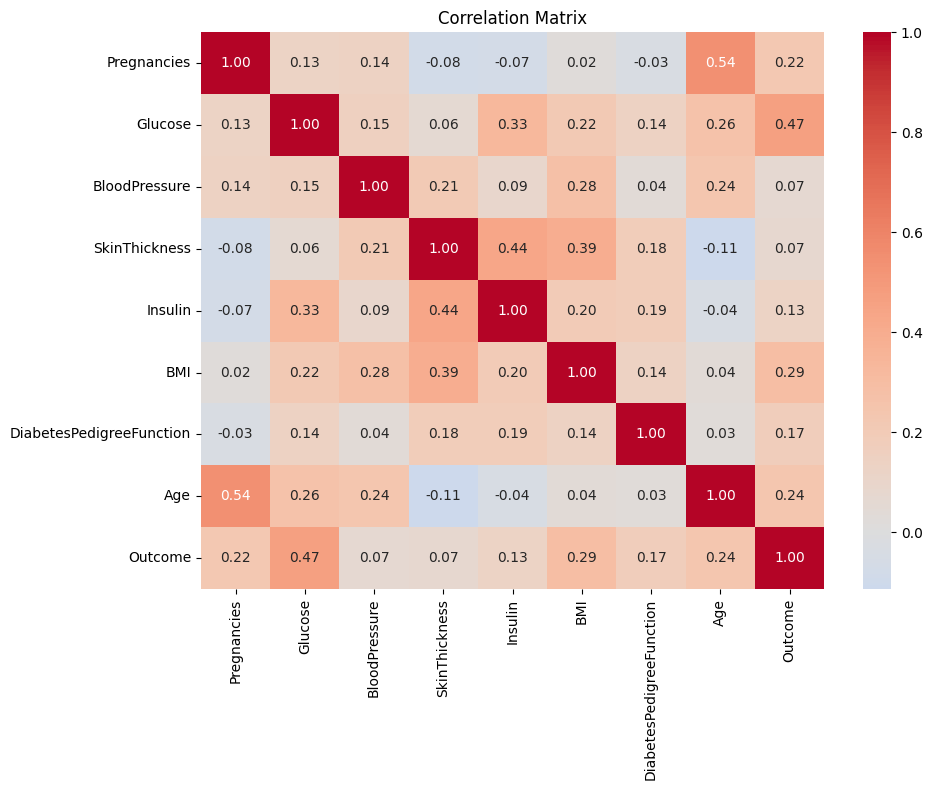

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

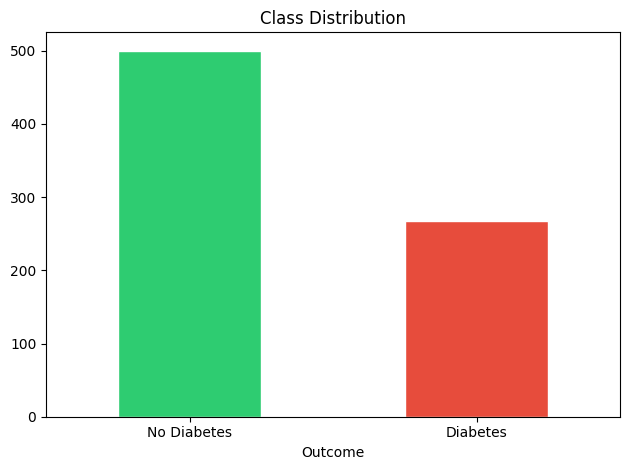

In [6]:
df['Outcome'].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c'], edgecolor='white')
plt.xticks([0,1], ['No Diabetes','Diabetes'], rotation=0)
plt.title('Class Distribution')
plt.tight_layout()
plt.show()

## Step 3: Preprocessing

In [7]:
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[zero_cols] = df[zero_cols].replace(0, np.nan)
df.fillna(df.median(), inplace=True)
print('Missing after imputation:', df.isnull().sum().sum())

Missing after imputation: 0


In [8]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_scaled, y)
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (800, 8), Test: (200, 8)


## Step 4: Baseline Model

In [9]:
baseline = RandomForestClassifier(n_estimators=100, random_state=42)
baseline.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, baseline.predict(X_test))
baseline_auc = roc_auc_score(y_test, baseline.predict_proba(X_test)[:,1])
print(f'Baseline Accuracy : {baseline_acc:.4f}')
print(f'Baseline ROC-AUC  : {baseline_auc:.4f}')

Baseline Accuracy : 0.8300
Baseline ROC-AUC  : 0.9100


## Step 5: Hyperparameter Tuning (GridSearchCV)

In [10]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)
print('Best Parameters:', grid_search.best_params_)
print('Best CV ROC-AUC:', f'{grid_search.best_score_:.4f}')

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV ROC-AUC: 0.8915


## Step 6: Tuned Model Evaluation

In [11]:
model = grid_search.best_estimator_
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
tuned_acc = accuracy_score(y_test, y_pred)
tuned_auc = roc_auc_score(y_test, y_prob)
print(f'Tuned Accuracy : {tuned_acc:.4f}  (Baseline: {baseline_acc:.4f})  Gain: {tuned_acc - baseline_acc:+.4f}')
print(f'Tuned ROC-AUC  : {tuned_auc:.4f}  (Baseline: {baseline_auc:.4f})  Gain: {tuned_auc - baseline_auc:+.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred, target_names=['No Diabetes','Diabetes']))

Tuned Accuracy : 0.8200  (Baseline: 0.8300)  Gain: -0.0100
Tuned ROC-AUC  : 0.9027  (Baseline: 0.9100)  Gain: -0.0073

Classification Report:
               precision    recall  f1-score   support

 No Diabetes       0.87      0.75      0.81       100
    Diabetes       0.78      0.89      0.83       100

    accuracy                           0.82       200
   macro avg       0.83      0.82      0.82       200
weighted avg       0.83      0.82      0.82       200



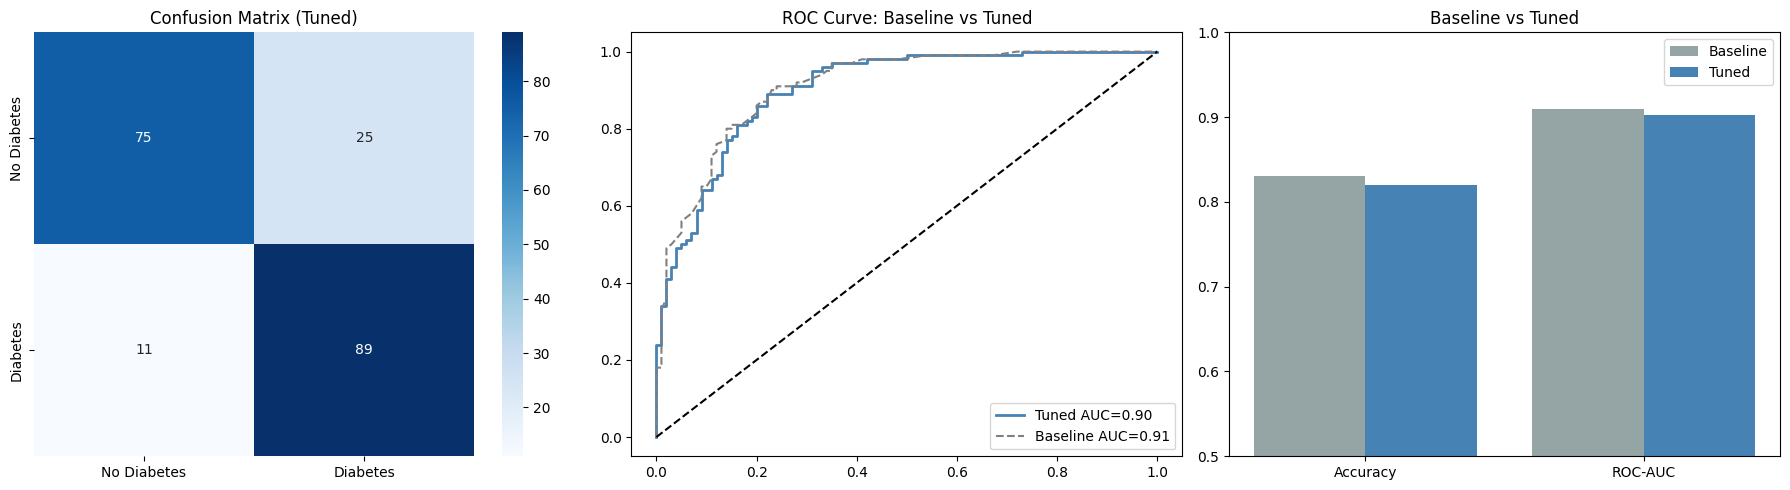

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Diabetes','Diabetes'], yticklabels=['No Diabetes','Diabetes'])
axes[0].set_title('Confusion Matrix (Tuned)')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'Tuned AUC={tuned_auc:.2f}')
fpr_b, tpr_b, _ = roc_curve(y_test, baseline.predict_proba(X_test)[:,1])
axes[1].plot(fpr_b, tpr_b, color='gray', lw=1.5, linestyle='--', label=f'Baseline AUC={baseline_auc:.2f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve: Baseline vs Tuned')
axes[1].legend()

# Baseline vs Tuned comparison bar
metrics = ['Accuracy', 'ROC-AUC']
baseline_vals = [baseline_acc, baseline_auc]
tuned_vals = [tuned_acc, tuned_auc]
x = np.arange(len(metrics))
axes[2].bar(x - 0.2, baseline_vals, 0.4, label='Baseline', color='#95a5a6')
axes[2].bar(x + 0.2, tuned_vals, 0.4, label='Tuned', color='steelblue')
axes[2].set_xticks(x)
axes[2].set_xticklabels(metrics)
axes[2].set_ylim(0.5, 1.0)
axes[2].set_title('Baseline vs Tuned')
axes[2].legend()
plt.tight_layout()
plt.show()

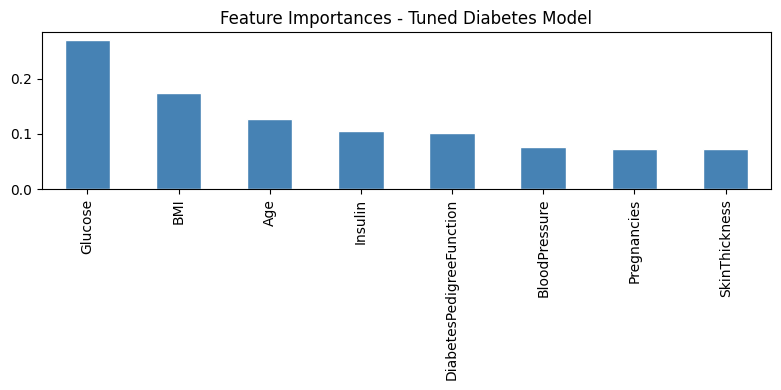

In [13]:
feat_imp = pd.Series(model.feature_importances_, index=df.columns[:-1]).sort_values(ascending=False)
feat_imp.plot(kind='bar', color='steelblue', edgecolor='white', figsize=(8,4))
plt.title('Feature Importances - Tuned Diabetes Model')
plt.tight_layout()
plt.show()

## Step 7: Save Model

In [ ]:
joblib.dump(model, '../models/diabetes_model.pkl')
joblib.dump(scaler, '../models/diabetes_scaler.pkl')
print('Diabetes tuned model and scaler saved!')